# Basin persistence on AHN DTM — flat-terrain TDA

**Question.** Can persistent homology identify topologically meaningful water-accumulation basins in low-relief Dutch terrain?

**Why this works.** On a sublevel-set filtration $\{x : f(x) \le t\}$, raising $t$ is exactly raising a water level. Each $H_0$ feature is born at a local minimum (a basin starts filling) and dies at a saddle (it spills into a neighbour). So **persistence = death − birth = the water depth required for that basin to overflow.** This single object answers all three of the prof's prompts:

- *Where are the minima/maxima?* → birth cells of $H_0$ on $f$ (minima) and on $-f$ (maxima).
- *Which are relevant?* → high-persistence pairs.
- *Compare regions.* → side-by-side persistence diagrams + bottleneck distance.

**Plan in this notebook (cells 1–10).**
1. Load AHN DTM tiles (0.5 m, EPSG:28992) for two flat regions: Amsterdam centre and Eindhoven north.
2. Visualize each region at 2 m (overview) — this is our cell-5/6 baseline figure.
3. Pick a 0.5 m zoom AOI, preprocess (handle nodata over water), visualize.
4. Detect Morse critical points (minima/maxima) on the zoom.
5. Run sublevel-set persistence with gudhi's cubical complex; plot the persistence diagram.

Basin extraction (mapping high-persistence pairs back to spatial polygons) and cross-region comparison live in the next notebook.


In [ ]:
# Cell 2 — imports
from pathlib import Path
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.merge import merge as rio_merge
from scipy import ndimage

import gudhi as gd

print(f"numpy {np.__version__}")
print(f"rasterio {rasterio.__version__}")
print(f"gudhi {gd.__version__}")


numpy      2.4.4
rasterio   1.5.0
gudhi      3.12.0


In [ ]:
# Cell 3 — paths and AOIs
#
# Data lives in the repo's own data/ folder (same convention as TDA_Data_Imputation.ipynb)
# We walk up the tree until we find requirements.txt to locate the repo root reliably,
# regardless of which directory the kernel was launched from.

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "requirements.txt").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "requirements.txt").exists():
    raise FileNotFoundError(
        "requirements.txt not found. Make sure the kernel is running inside the repo."
    )

DATA_DIR = REPO_ROOT / "data"

assert DATA_DIR.exists(), f"DATA_DIR does not exist: {DATA_DIR}"
print(f"REPO_ROOT = {REPO_ROOT}")
print(f"DATA_DIR  = {DATA_DIR}\n")

# Pre-merged regional strips (one file per region)
def _check(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing data file: {path}")
    return path

AMSTERDAM_TILES = [_check(DATA_DIR / "amsterdam_centre_strip.tif")]
EINDHOVEN_TILES = [_check(DATA_DIR / "eindhoven_north_strip.tif")]

# Print each file's geo-metadata so we can verify CRS / extent / native resolution
for label, paths in [("Amsterdam", AMSTERDAM_TILES), ("Eindhoven", EINDHOVEN_TILES)]:
    with rasterio.open(paths[0]) as src:
        b = src.bounds
        print(f"{label}: {paths[0].name}")
        print(f"    crs        {src.crs}")
        print(f"    resolution {src.res[0]:.2f} m")
        print(f"    extent     X [{b.left:.0f}, {b.right:.0f}]  Y [{b.bottom:.0f}, {b.top:.0f}]")
        print(f"    shape      {src.height} x {src.width} = {src.height * src.width / 1e6:.1f} M cells\n")

# AOIs: pass None to use the file's full extent (cells 5 & 6 below).
# The strips are already clipped to their regions, so we don't need to clip again.
AOI_AMSTERDAM = None
AOI_EINDHOVEN = None

# Resolutions: overview for the whole strip, native zoom for a sub-AOI.
RES_OVERVIEW = 2.0   # metres per pixel
RES_ZOOM = 0.5   # metres per pixel — AHN native

In [ ]:
# Cell 4 — raster helpers
#
# Single-file path now uses a direct windowed read (no merge). Multi-file path
# still uses rasterio.merge. Nodata masking is hardened against precision drift
# in the float32 sentinel (~3.4e38)

NODATA_MAGNITUDE = 1e30  # any |value| larger than this is treated as nodata


def block_mean_nanaware(arr, transform, factor):
    """Downsample by averaging factor*factor blocks; NaN-aware."""
    if factor == 1:
        return arr, transform
    h, w = arr.shape
    h2, w2 = (h // factor) * factor, (w // factor) * factor
    arr = arr[:h2, :w2]
    arr = arr.reshape(h2 // factor, factor, w2 // factor, factor)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)  # all-NaN slices
        arr = np.nanmean(arr, axis=(1, 3))
    new_transform = transform * transform.scale(factor, factor)
    return arr.astype(np.float32), new_transform


def _mask_nodata(arr, nodata):
    """Set nodata pixels to NaN. Robust to precision drift in the sentinel."""
    arr = arr.astype(np.float32, copy=True)
    if nodata is not None and np.isfinite(nodata):
        arr[arr == np.float32(nodata)] = np.nan
    # Defensive: any extreme float32 sentinel (covers ~MAX_FLOAT32 ≈ 3.4e38).
    arr[np.abs(arr) > NODATA_MAGNITUDE] = np.nan
    return arr


def load_dtm_bbox(file_paths, bbox=None, target_res=None):
    """
    Read AHN DTM tile(s), optionally clip to a bbox, optionally downsample.

    Single-file -> direct windowed read.
    Multi-file  -> rasterio.merge.
    """
    if not file_paths:
        raise FileNotFoundError("No tile files passed to load_dtm_bbox.")

    if len(file_paths) == 1:
        from rasterio.windows import from_bounds
        with rasterio.open(file_paths[0]) as src:
            if bbox is not None:
                window = from_bounds(*bbox, transform=src.transform)
                arr = src.read(1, window=window)
                transform = src.window_transform(window)
            else:
                arr = src.read(1)
                transform = src.transform
            crs = src.crs
            nodata = src.nodata
    else:
        srcs = [rasterio.open(p) for p in file_paths]
        try:
            if bbox is not None:
                merged, transform = rio_merge(srcs, bounds=bbox)
            else:
                merged, transform = rio_merge(srcs)
            crs = srcs[0].crs
            nodata = srcs[0].nodata
        finally:
            for s in srcs:
                s.close()
        arr = merged[0]

    arr = _mask_nodata(arr, nodata)

    if target_res is not None:
        native = abs(transform.a)
        factor = int(round(target_res / native))
        if factor < 1:
            raise ValueError(f"target_res {target_res} m < native {native} m; can't upsample.")
        arr, transform = block_mean_nanaware(arr, transform, factor)

    return arr, transform, crs


def array_extent(transform, shape):
    """Return (xmin, xmax, ymin, ymax) for matplotlib imshow extent."""
    h, w = shape
    xmin = transform.c
    ymax = transform.f
    xmax = xmin + w * transform.a
    ymin = ymax + h * transform.e
    return (xmin, xmax, ymin, ymax)


def show_dtm(arr, transform, title, ax=None, vmin=None, vmax=None, cmap="terrain"):
    """Plot a DTM array with NAP elevation colourbar and RD-New axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    finite = arr[np.isfinite(arr)]
    if vmin is None: vmin = np.nanpercentile(finite, 1)
    if vmax is None: vmax = np.nanpercentile(finite, 99)
    extent = array_extent(transform, arr.shape)
    im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap,
                   vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_xlabel("X (RD New, m)")
    ax.set_ylabel("Y (RD New, m)")
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
    cb.set_label("Elevation (m NAP)")
    return ax

shape      (6250, 2500)
resolution 2.00 m
crs        EPSG:28992
valid      67.7% of pixels
elevation  min=-9.70  max=16.02  mean=-0.18 m NAP


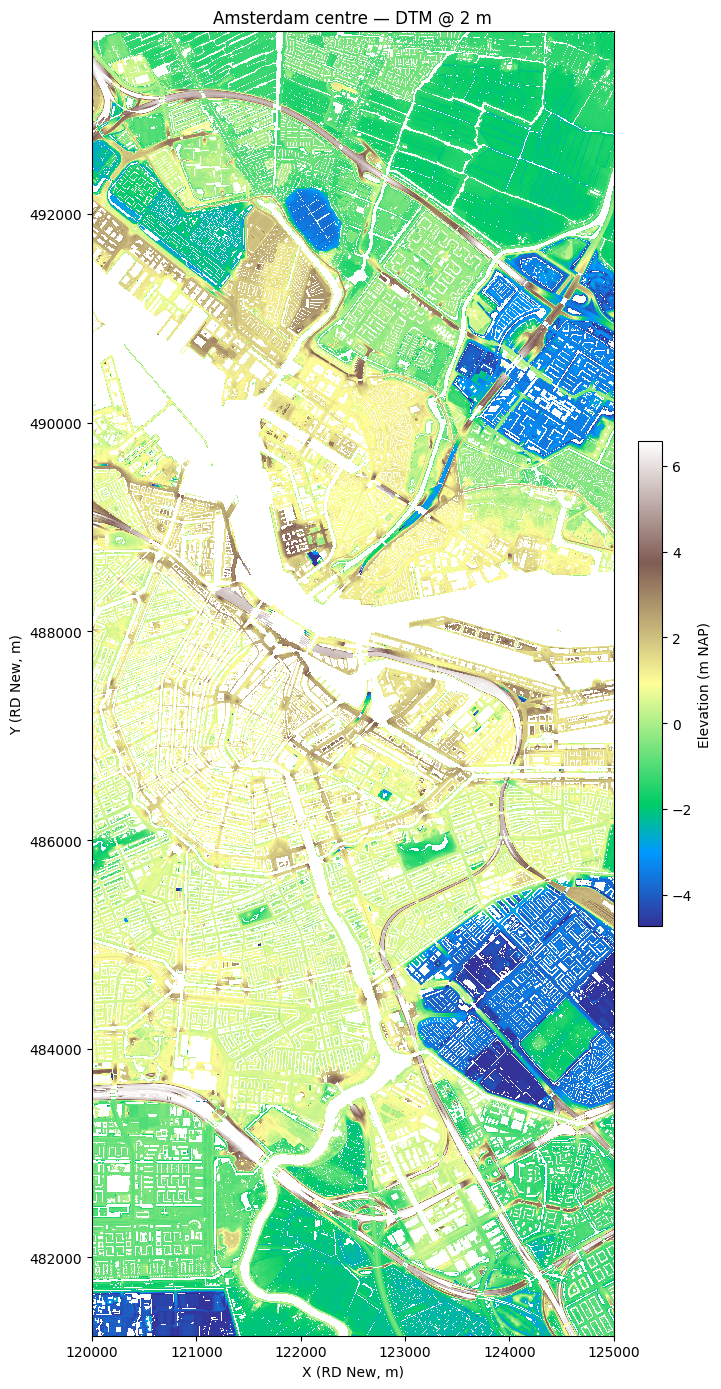

In [ ]:
# Cell 5 — Amsterdam centre, 2 m overview
arr_ams, tr_ams, crs_ams = load_dtm_bbox(
    AMSTERDAM_TILES, bbox=AOI_AMSTERDAM, target_res=RES_OVERVIEW,
)
print(f"shape {arr_ams.shape}")
print(f"resolution {abs(tr_ams.a):.2f} m")
print(f"crs {crs_ams}")
print(f"valid {np.mean(np.isfinite(arr_ams)) * 100:.1f}% of pixels")
print(f"elevation min={np.nanmin(arr_ams):.2f}, max={np.nanmax(arr_ams):.2f}, mean={np.nanmean(arr_ams):.2f} m NAP")

fig, ax = plt.subplots(figsize=(7, 14))
show_dtm(arr_ams, tr_ams, "Amsterdam centre — DTM @ 2 m", ax=ax)
plt.tight_layout()
plt.show()


shape      (3125, 5000)
resolution 2.00 m
valid      83.7% of pixels
elevation  min=10.44  max=35.01  mean=18.39 m NAP
loaded extent: X [155000, 165000]  Y [381250, 387500]


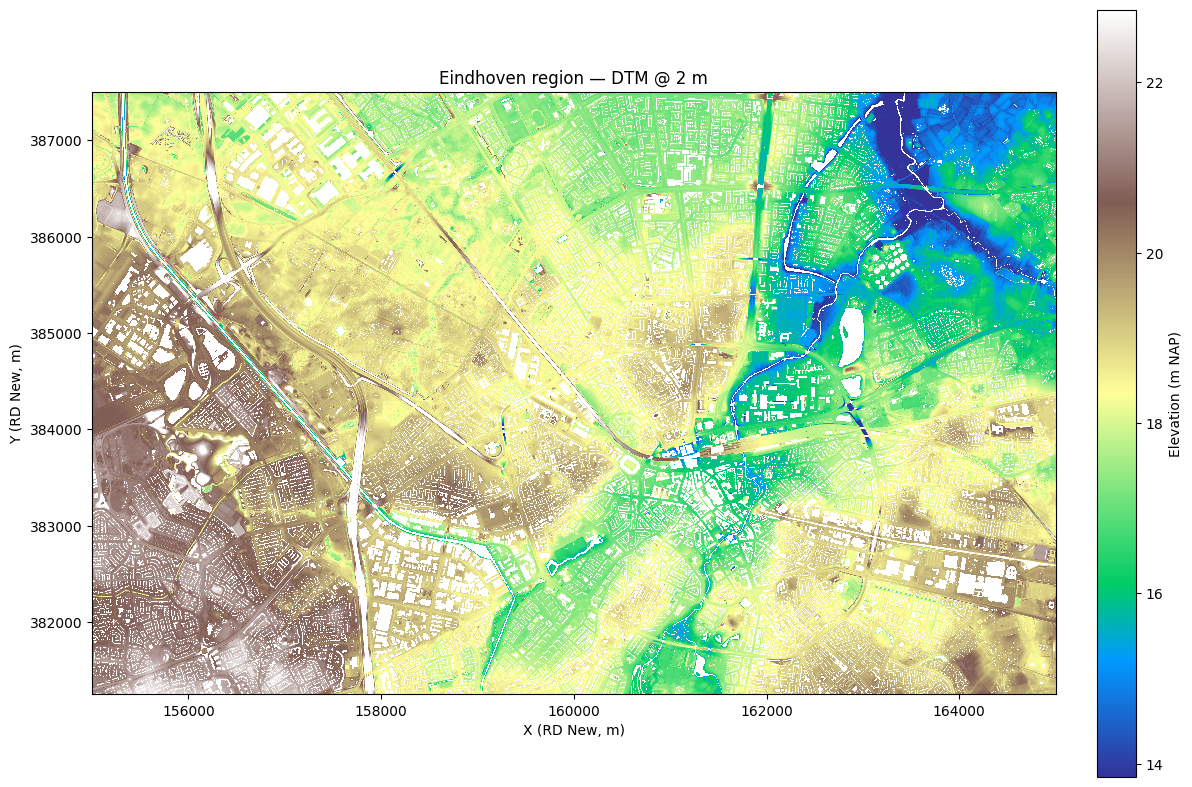

In [ ]:
# Cell 6 — Eindhoven north, 2 m overview
arr_ehv, tr_ehv, crs_ehv = load_dtm_bbox(
    EINDHOVEN_TILES, bbox=AOI_EINDHOVEN, target_res=RES_OVERVIEW,
)
print(f"shape {arr_ehv.shape}")
print(f"resolution {abs(tr_ehv.a):.2f} m")
print(f"valid {np.mean(np.isfinite(arr_ehv)) * 100:.1f}% of pixels")
print(f"elevation min={np.nanmin(arr_ehv):.2f}, max={np.nanmax(arr_ehv):.2f}, mean={np.nanmean(arr_ehv):.2f} m NAP")

# Use the bounds of what we actually loaded to suggest a default zoom AOI.
xmin, xmax, ymin, ymax = array_extent(tr_ehv, arr_ehv.shape)
print(f"loaded extent: X [{xmin:.0f}, {xmax:.0f}]  Y [{ymin:.0f}, {ymax:.0f}]")

fig, ax = plt.subplots(figsize=(12, 8))
show_dtm(arr_ehv, tr_ehv, "Eindhoven region — DTM @ 2 m", ax=ax)
plt.tight_layout()
plt.show()


## Zoom into one region at native 0.5 m resolution

Pick a ~1 × 1 km sub-AOI from the overview where the basin question is interesting. The default below puts the zoom on the Amsterdam canal ring (Jordaan / Centrum). For Eindhoven, set `ZOOM_REGION = "eindhoven"` and adjust `AOI_ZOOM` based on the cell-6 plot.


Amsterdam (canal ring):
  shape      (2000, 2000)
  resolution 0.50 m
  valid      36.7% of pixels
  elevation  min=-4.10  max=4.85  mean=1.41 m NAP
Eindhoven (Dommel valley):
  shape      (2000, 2000)
  resolution 0.50 m
  valid      73.4% of pixels
  elevation  min=12.09  max=20.88  mean=16.67 m NAP


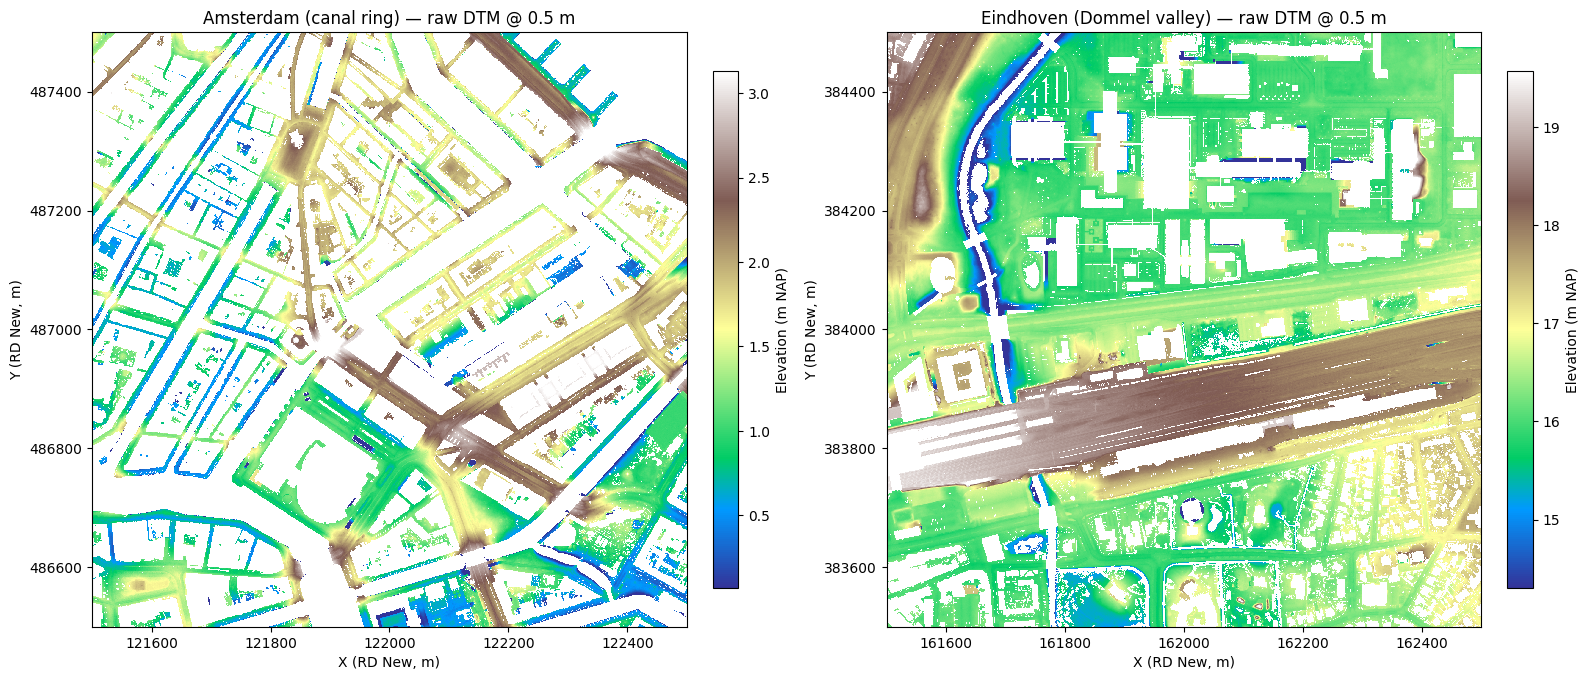

In [ ]:
# Cell 7 — load BOTH zoom AOIs at 0.5 m
#
# Amsterdam canal ring (anthropogenic basins) + Eindhoven Dommel valley
# (natural fluvial relief). Each AOI is ~1×1 km. Results accumulate into the
# `zooms` dict, which subsequent cells extend in place.

zooms = {
    "amsterdam": {
        "tiles":       AMSTERDAM_TILES,
        "bbox":        (121_500, 486_500, 122_500, 487_500),  # canal ring / Centrum
        "water_level": -0.40,                                 # Amsterdam stadsboezem
        "label":       "Amsterdam (canal ring)",
    },
    "eindhoven": {
        "tiles":       EINDHOVEN_TILES,
        "bbox":        (161_500, 383_500, 162_500, 384_500),  # Dommel valley
        "water_level": +14.0,                                 # local Dommel surface
        "label":       "Eindhoven (Dommel valley)",
    },
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (region, d) in zip(axes, zooms.items()):
    arr, tr, crs = load_dtm_bbox(d["tiles"], bbox=d["bbox"], target_res=RES_ZOOM)
    d["arr"] = arr
    d["transform"] = tr
    d["crs"] = crs
    print(f"{d['label']}:")
    print(f"  shape      {arr.shape}")
    print(f"  resolution {abs(tr.a):.2f} m")
    print(f"  valid      {np.mean(np.isfinite(arr))*100:.1f}% of pixels")
    print(f"  elevation  min={np.nanmin(arr):.2f}  max={np.nanmax(arr):.2f}  "
          f"mean={np.nanmean(arr):.2f} m NAP")
    show_dtm(arr, tr, f"{d['label']} — raw DTM @ 0.5 m", ax=ax)
plt.tight_layout()
plt.show()

## Preprocessing: how do we treat open water?

AHN DTM has nodata over open water (canals, IJ, ponds). Three options for our basin question:

1. **Leave as nodata** → the cubical complex treats those cells as $+\infty$. Basins next to canals will look artificially deep because the canal surface acts like a wall.
2. **Fill with the local water-surface elevation** → physically correct for the flood interpretation. Amsterdam canals sit at ≈ −0.40 m NAP (the regulated stadsboezem). Eindhoven's Dommel is ≈ +16 m NAP locally.
3. **Clip the AOI to exclude large water bodies** → avoids the question but loses context.

We go with option 2. Set `WATER_LEVEL` to your AOI's known canal surface; the cell fills only the nodata pixels and reports how many were filled.


Amsterdam (canal ring): filled 2,531,572 pixels (63.3%) at -0.40 m NAP
Eindhoven (Dommel valley): filled 1,064,878 pixels (26.6%) at +14.00 m NAP


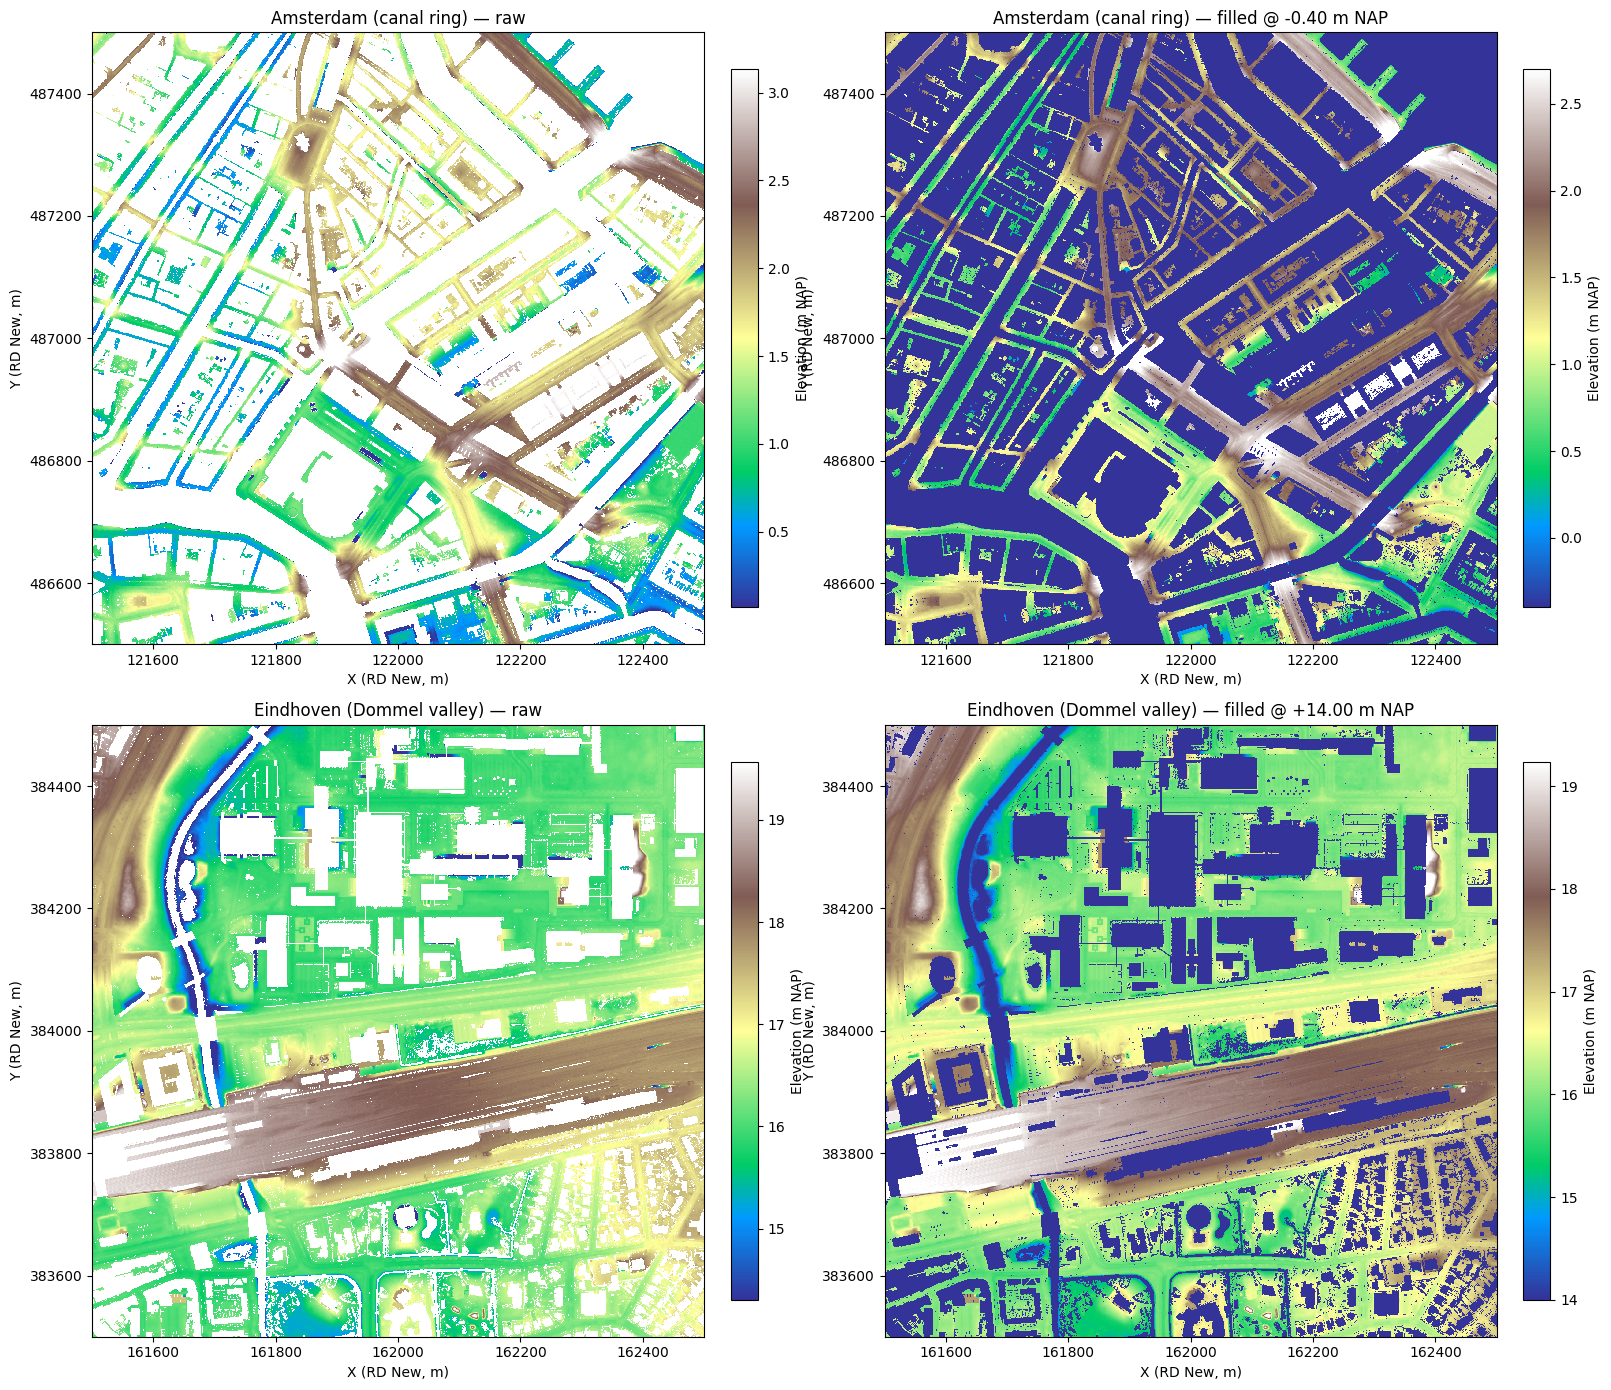

In [8]:
# Cell 8 — fill nodata over open water for both zooms
#
# Amsterdam canals → −0.40 m NAP; Dommel → +14.0 m NAP (set in cell 7's `zooms`).
# Plot is 2 rows × 2 cols: each row = one region, columns are raw vs filled.

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for row, (region, d) in enumerate(zooms.items()):
    arr = d["arr"]
    nodata_mask = ~np.isfinite(arr)
    filled = arr.copy()
    filled[nodata_mask] = d["water_level"]
    d["filled"] = filled
    d["nodata_mask"] = nodata_mask

    print(f"{d['label']}: filled {nodata_mask.sum():,} pixels "
          f"({nodata_mask.mean()*100:.1f}%) at {d['water_level']:+.2f} m NAP")

    show_dtm(arr,    d["transform"], f"{d['label']} — raw",                          ax=axes[row, 0])
    show_dtm(filled, d["transform"], f"{d['label']} — filled @ {d['water_level']:+.2f} m NAP",
             ax=axes[row, 1])
plt.tight_layout(); plt.show()

## Discrete Morse: local minima and maxima

Local minima of $f$ are where basins are born; local maxima of $f$ are where basins of $-f$ are born (i.e. peaks). At this stage we just enumerate them on an 8-neighbour stencil — **without** any persistence filtering yet. Expect *many* of them; that's exactly what motivates the next cell.

(Saddles are not detected separately here — we let persistence pair them up with their basin in cell 10. Every finite $H_0$ death is a saddle.)


Amsterdam (canal ring):  raw minima 73,293   raw maxima 97,983
Eindhoven (Dommel valley):  raw minima 171,994   raw maxima 193,391


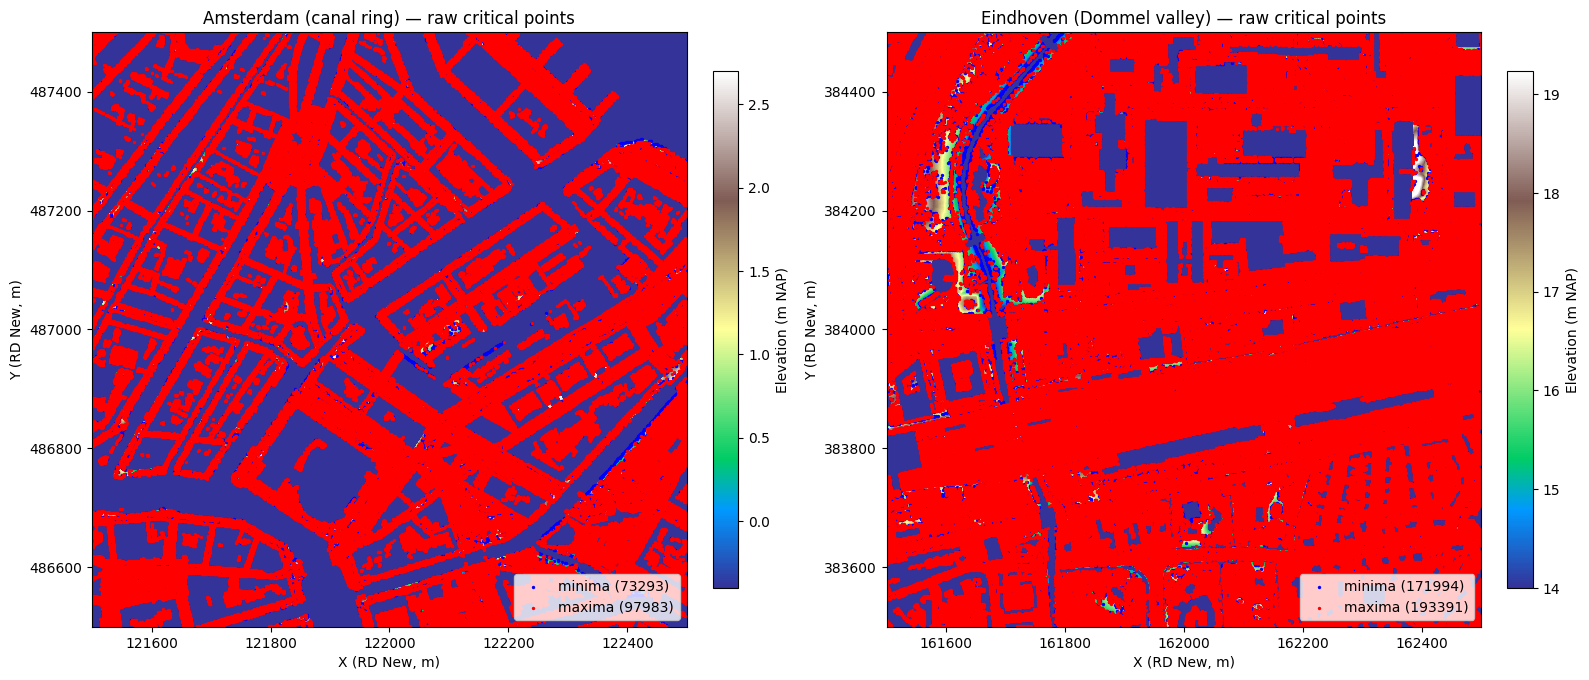

In [9]:
# Cell 9 — strict local minima/maxima for both zooms (8-neighbour, plateau-collapsed)

def critical_points(arr, kind="min"):
    """Strict local extrema on a 3x3 neighbourhood. Plateaus collapse to one rep cell."""
    if kind == "min":
        a = np.where(np.isnan(arr), np.inf, arr)
        flag = a == ndimage.minimum_filter(a, size=3, mode="constant", cval=np.inf)
    elif kind == "max":
        a = np.where(np.isnan(arr), -np.inf, arr)
        flag = a == ndimage.maximum_filter(a, size=3, mode="constant", cval=-np.inf)
    else:
        raise ValueError("kind must be 'min' or 'max'")
    labels, n = ndimage.label(flag)
    if n == 0:
        return np.zeros_like(flag)
    out = np.zeros_like(flag)
    flat_lbl = labels.ravel()
    seen = set()
    for i, l in enumerate(flat_lbl):
        if l > 0 and l not in seen:
            out.ravel()[i] = True
            seen.add(l)
    return out

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (region, d) in zip(axes, zooms.items()):
    elev = d["filled"]
    mins = critical_points(elev, kind="min")
    maxs = critical_points(elev, kind="max")
    d["mins"] = mins
    d["maxs"] = maxs
    print(f"{d['label']}:  raw minima {mins.sum():,}   raw maxima {maxs.sum():,}")

    extent = array_extent(d["transform"], elev.shape)
    show_dtm(elev, d["transform"], f"{d['label']} — raw critical points", ax=ax)
    ys, xs = np.where(mins)
    ax.scatter(extent[0] + xs * abs(d["transform"].a),
               extent[3] + ys * d["transform"].e,
               s=2, c="blue", label=f"minima ({mins.sum()})")
    ys, xs = np.where(maxs)
    ax.scatter(extent[0] + xs * abs(d["transform"].a),
               extent[3] + ys * d["transform"].e,
               s=2, c="red", label=f"maxima ({maxs.sum()})")
    ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## Sublevel-set persistence

We build a 2D cubical complex with `top_dimensional_cells = elevation`. Gudhi's V-construction filters lower cells by the minimum of adjacent pixels, so the resulting filtration is exactly $\{f \le t\}$.

What we get back:
- $H_0$ pairs: one per basin. Birth = elevation of the basin's deepest point. Death = elevation of the saddle where it overflows (= $+\infty$ for the global minimum, which lives forever).
- $H_1$ pairs: one per "ring" / island enclosed by the rising water. Less central to the flood question, but plotted for completeness.

Persistence (death − birth) for an $H_0$ pair is the **spillover depth** of that basin in metres.


Amsterdam (canal ring):  H0 pairs 69,805   H1 pairs 193,475
  saved → c:\Users\david\OneDrive\Desktop\TU-e\First_Year\4th_Block\Topological Analysis\Terrain-elevation-data-TDA\outputs\persistence_amsterdam_zoom.npz
Eindhoven (Dommel valley):  H0 pairs 167,064   H1 pairs 369,936
  saved → c:\Users\david\OneDrive\Desktop\TU-e\First_Year\4th_Block\Topological Analysis\Terrain-elevation-data-TDA\outputs\persistence_eindhoven_zoom.npz


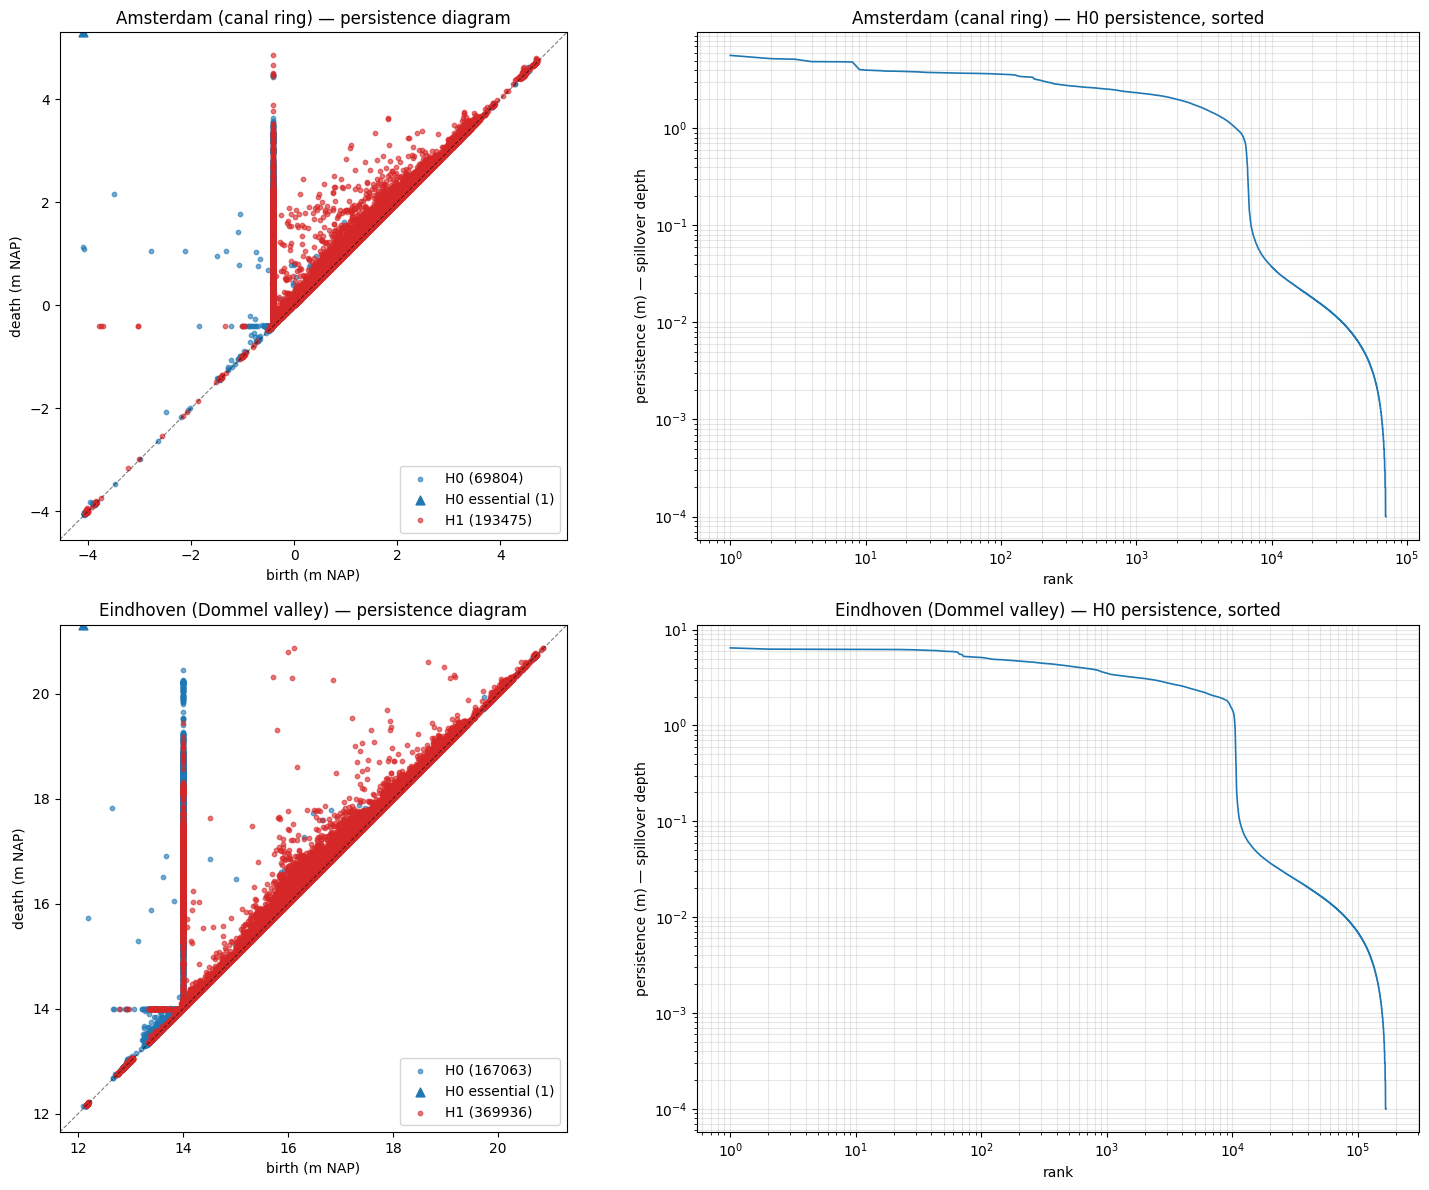

In [10]:
# Cell 10 — sublevel-set persistence for both zooms
#
# Computes H0 + H1 via gudhi cubical complex, plots diagram + sorted-persistence
# curve per region (2x2 grid), and saves both .npz files for the next notebook.

out = REPO_ROOT / "outputs"
out.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for row, (region, d) in enumerate(zooms.items()):
    elev = d["filled"]
    cc = gd.CubicalComplex(top_dimensional_cells=elev.astype(np.float64))
    cc.compute_persistence(homology_coeff_field=2, min_persistence=0.0)
    pairs = cc.persistence()
    h0 = np.array([(b, dth) for dim, (b, dth) in pairs if dim == 0], dtype=float)
    h1 = np.array([(b, dth) for dim, (b, dth) in pairs if dim == 1], dtype=float)
    d["h0"] = h0
    d["h1"] = h1
    print(f"{d['label']}:  H0 pairs {len(h0):,}   H1 pairs {len(h1):,}")

    # --- Persistence diagram ---
    ax = axes[row, 0]
    finite_max = np.nanmax(elev); finite_min = np.nanmin(elev)
    pad = 0.05 * (finite_max - finite_min)
    lo, hi = finite_min - pad, finite_max + pad
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
    if len(h0):
        finite = np.isfinite(h0[:, 1])
        ax.scatter(h0[finite, 0], h0[finite, 1], s=10, c="C0", alpha=0.6,
                   label=f"H0 ({finite.sum()})")
        n_inf = (~finite).sum()
        if n_inf:
            ax.scatter(h0[~finite, 0], np.full(n_inf, hi), s=40, c="C0",
                       marker="^", label=f"H0 essential ({n_inf})")
    if len(h1):
        finite = np.isfinite(h1[:, 1])
        ax.scatter(h1[finite, 0], h1[finite, 1], s=10, c="C3", alpha=0.6,
                   label=f"H1 ({finite.sum()})")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("birth (m NAP)"); ax.set_ylabel("death (m NAP)")
    ax.set_title(f"{d['label']} — persistence diagram")
    ax.legend(loc="lower right"); ax.set_aspect("equal")

    # --- Sorted-persistence curve ---
    ax = axes[row, 1]
    if len(h0):
        pers = h0[:, 1] - h0[:, 0]
        pers = pers[np.isfinite(pers)]
        ps = np.sort(pers)[::-1]
        ax.plot(np.arange(1, len(ps)+1), ps, lw=1.2)
        ax.set_yscale("log"); ax.set_xscale("log")
        ax.set_xlabel("rank"); ax.set_ylabel("persistence (m) — spillover depth")
        ax.set_title(f"{d['label']} — H0 persistence, sorted")
        ax.grid(True, which="both", alpha=0.3)

    # --- Save for the next notebook ---
    tr = d["transform"]
    np.savez(out / f"persistence_{region}_zoom.npz",
             h0=h0, h1=h1,
             elevation=elev,
             transform=np.array([tr.a, tr.b, tr.c, tr.d, tr.e, tr.f]),
             water_level=d["water_level"])
    print(f"  saved → {out / f'persistence_{region}_zoom.npz'}")

plt.tight_layout(); plt.show()

## What's next (next notebook)

Cells 1–10 give us **what's there** topologically. The next notebook (`02_basin_extraction.ipynb`) does:

11. **Persistence threshold sweep.** Use the sorted-persistence plot's elbow to pick $\tau$ (in metres of spillover depth). Document why.
12. **Map basins back to space.** For each $H_0$ pair with persistence $> \tau$: birth cell = basin minimum, death cell = spillover saddle, basin region = component of $\{f \le \text{saddle elev}\}$ containing the minimum.
13. **Quantify per region.** Basin count, basin area (m²), water storage volume $\int (\text{saddle} - f)\, dA$.
14. **Cross-region comparison.** Side-by-side persistence diagrams for Amsterdam vs Eindhoven; one-number summary via gudhi's bottleneck distance.
15. **Discussion.** Which features are real (subway entrances, tunnels, polder corners, locks) vs artefacts (bridge decks left in DTM, building-footprint imperfections). Overlay against a real flood map if available.

Full deliverable: minima/maxima → relevance filtering → spatial interpretation → cross-region comparison, all from one persistence object.
